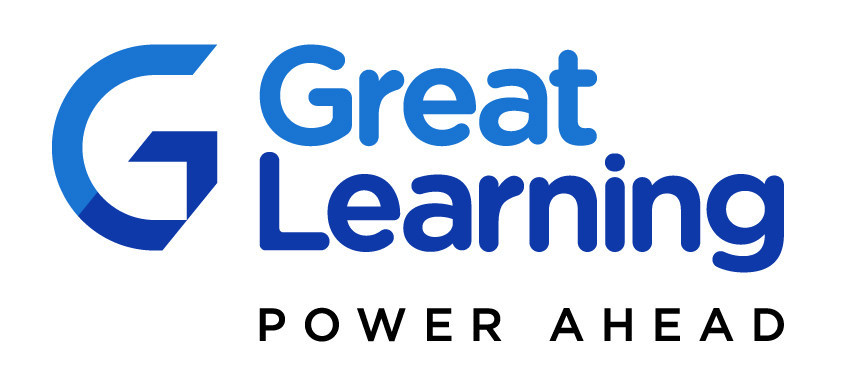

# **GA-NLP Mid-term Project: Support Ticket Categorization**

## **Business Context**

In today's dynamic business landscape, organizations are increasingly recognizing the pivotal role customer feedback plays in shaping the trajectory of their products and services. The ability to **swiftly and effectively respond to customer input** not only fosters enhanced customer experiences but also serves as a catalyst for growth, prolonged customer engagement, and the nurturing of lifetime value relationships.

As a dedicated Product Manager or Product Analyst, staying attuned to the voice of your customers is not just a best practice; it's a strategic imperative.

While your organization may be inundated with a wealth of customer-generated feedback and support tickets, your role entails much more than just processing these inputs. To make your efforts in managing customer experience and expectations truly impactful, you need a structured approach – a method that allows you to discern the most pressing issues, set priorities, and allocate resources judiciously.

One of the most effective strategies at your disposal as an organization is to harness the power of automated Support Ticket Categorization - **done in the modern day using Large Language Models and Generative AI.**


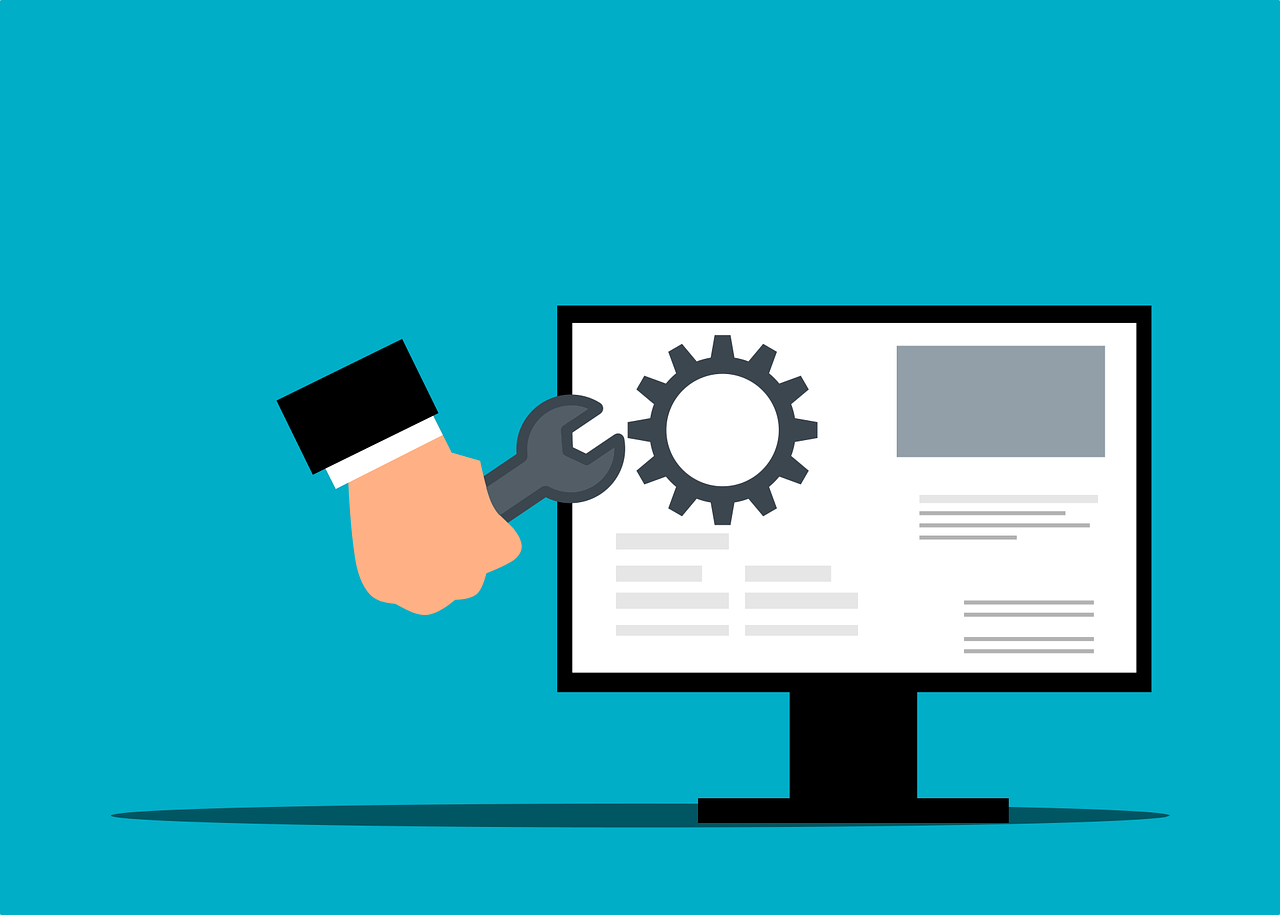

## **Project Objective**

Develop a Generative AI application using a Large Language Model to **automate the classification and processing of support tickets.** The application will aim to predict ticket categories, assign priority, suggest estimated resolution times, generate responses based on sentiment analysis, and store the results in a structured DataFrame.


## **Expected Output**

## **Model Loading**

In [ ]:
#Check if CUDA is supported
import torch
print(torch.cuda.is_available())

True


In [ ]:
# Installation for GPU llama-cpp-python
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.28 --force-reinstall --upgrade --no-cache-dir --verbose

Using pip 23.1.2 from /usr/local/lib/python3.10/dist-packages/pip (python 3.10)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 28.5 MB/s eta 0:00:00
  Running command pip subprocess to install build dependencies
  Using pip 23.1.2 from /usr/local/lib/python3.10/dist-packages/pip (python 3.10)
       ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.6/151.6 kB 4.6 MB/s eta 0:00:00
       ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Running command Getting requirements to build wheel
  Could not determine CMake version via --version, got '' 'Traceback (most recent call last):\n  File "/usr/local/bin/cmake", line 5, in <module>\n    from cmake import cmake\nModuleNotFoundError: No module named \'cmake\'\n'
  Getting requirements to build wheel ... done
  Running command pip subprocess to install backend dependencies
  Using pip 23.1.2 from /usr/local/lib/python3.10/dist-packages/pip (python 3.10)
       ━━━━━━━━

### **Q1: Write Python code that imports the 'hf_hub_download' function from the 'huggingface_hub' library and also imports the 'Llama' class from the 'llama_cpp' library.**
### **Ensure that the code is correctly formatted and ready for execution.** ****

In [ ]:
# !apt-get update
# !apt-get install -y nvidia-cuda-toolkit

In [ ]:
!pip install -U "transformers==4.40.0" --upgrade



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 26.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.40.2
    Uninstalling transformers-4.40.2:
      Successfully uninstalled transformers-4.40.2


In [ ]:
# Install the hugging face hub
!pip install huggingface_hub -q

In [ ]:
!pip install llama_cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu


Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cpu


In [ ]:
# Import the 'hf_hub_download' function from the 'huggingface_hub' library
from huggingface_hub import hf_hub_download


# Import the 'Llama' class from the 'llama_cpp' library
from llama_cpp import Llama


In [ ]:
# Define the model name or path as a string (You can find this info from hugging face website)

model_name_or_path = "TheBloke/Llama-2-13B-chat-GGUF"

# Define the model basename as a string, indicating it's in the gguf format

model_basename = "llama-2-13b-chat.Q5_K_M.gguf"

In [ ]:
#Load the Secret to Access Hugging Face Hub
from google.colab import userdata
userdata.get('HuggingFace')

'YOUR_HF_TOKEN_HERE'

In [ ]:
# Download the model from the Hugging Face Hub using the 'hf_hub_download' function
# by specifying the 'repo_id' and 'filename'
model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


llama-2-13b-chat.Q5_K_M.gguf:   0%|          | 0.00/9.23G [00:00<?, ?B/s]

In [ ]:
# Create an instance of the 'Llama' class with specified parameters

lcpp_llm = Llama(
    model_path=model_path,
    n_threads=2, # CPU cores
    n_batch=512, # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
    n_gpu_layers=43, # Change this value based on your model and your GPU VRAM pool.
    n_ctx=4096 # Context window
)

AVX = 1 | AVX_VNNI = 0 | AVX2 = 1 | AVX512 = 1 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 1 | SSE3 = 1 | SSSE3 = 1 | VSX = 0 | 


### **Q2: Define the System Message** ****

Write a Python function called **generate_llama_response** that takes a single parameter, support_ticket_text, which represents the user's support ticket text. Inside the function, you should perform the following tasks:

Define a system message as a string and assign it to the variable system_message.

- **Combine the support_ticket_text and system_message to create a prompt string.**

*Generate a response from the LLaMA model using the lcpp_llm instance with the following parameters:*

- prompt should be the combined prompt string.
- max_tokens should be set to 256.
- temperature should be set to 0.
- top_p should be set to 0.95.
- repeat_penalty should be set to 1.2.
- top_k should be set to 50.
- stop should be set as a list containing 'INST'.
- echo should be set to False.
Extract and return the response text from the generated response.

Don't forget to provide a value for the system_message variable before using it in the function.



*What content and instructions should be included in the system message to guide the technical assistant when processing support tickets? Please provide a detailed description of the information and guidelines that the system message should contain.*

Here's a detailed breakdown of what should be included:

- **Introduction (System Role):** Begin with an introductory statement that establishes the role of the system message. In this case, it's acting as a guide for a technical assistant.

- **Ticket Categorization:** Explain the primary task of the technical assistant, which is to classify the support ticket into specific categories. In this example, the categories are:
    - Technical Issues
    - Hardware Issues
    - Data Recovery

- **Response Options:** Clearly state that the assistant should only respond with one of the predefined categories, emphasizing that other responses are not acceptable.

- **Sub-Tasks:** Outline the secondary tasks that the technical assistant should perform once the category is identified. These sub-tasks include:
  - **Creating Tags:** Instruct the assistant to create tags that will help further classify the ticket.
  - **Assigning Priority:** Specify that the assistant should assign a priority level (e.g., "High" or "Normal") based on their understanding of the text.
  - **Suggesting ETA:** Guide the assistant to provide an estimated time for
resolving the issue mentioned in the ticket.
  - **Generating 1st Reply (Sentiment-Based):** Emphasize the importance of crafting a response that aligns with the sentiment expressed in the ticket.

- **General Instructions:** Offer general instructions that should be followed throughout the ticket processing, such as:

  - **Categorization:** Reiterate that the assistant should categorize the ticket only into the predefined categories.
  - **Reading Carefully:** Stress the importance of reading the support ticket text thoroughly and considering the overall sentiment before responding.
  - **Tone:** Emphasize that the tone of all responses should be polite and professional.
  - **Output Format:** Clearly specify the desired output format for the responses generated by the assistant. In this case, the output should be in JSON format.

##### **The output of the model should be in JSON format**

In [ ]:
#Import List
from typing import List

#Define the function used to generate a response from LLama
def generate_llama_response(support_ticket_text):


    #System Message Content
    system_message_content = """
      You are a guide for a technical assistant.

      Ensure the output is in JSON format, and do not start the response with certainly or sure, and begin the response with only the JSON key category

      Classify support tickets in the 3 categories listed below only. Do not use any other categories. The JSON key should be category.
      1. Technical Issues
      2. Hardware Issues
      3. Data Recovery.

      In addition do the following:
      1. Create tags to further help classify the tickets. Tags should not be more than 2 words and they should further categorize the review. The name of the JSON key should be Tag
      2. Assign a priority for the support such as High or Normal based on your understanding of the text. The name of the JSON key should be Priority
      3. Suggest an ETA as an estimate time in hours in resolving the issue mentioned in the ticket. The name of the key should be suggested_eta
      4. Craft a response to the support ticket that aligns with the sentiment expressed in the ticket. The name of the key should be generated_1st_reply

      To reiterate, only classify the tickets in the 3 categories above.

      Ensure to read the support ticket thoroughly and consider the overall sentiment before responding.

      Make sure the Tone of all responses should be polite and professional



    """

    # System message
    system_message =f"""<s>[INST]\n <<SYS>> \n {system_message_content} \n <</SYS>> \n [/INST] \n </s>"""

    # Combine user_prompt and system_message to create the prompt
    prompt = f"{system_message}\n{support_ticket_text}"

    # Generate a response from the LLAMA model
    response = lcpp_llm(
                prompt=prompt,
                temperature=0,
                top_p=0.95,
                repeat_penalty=1.2,
                top_k=50,
                max_tokens = 2000,
                stop=List['INST'],
                echo=False
              )
    # Extract and return the response text
    response_text = response["choices"][0]["text"]  ### Fill in the blank
    return response_text



### **Q3: Loading our Dataset**

In [ ]:
# Import the pandas library and alias it as 'pd'
import pandas as pd

# The data set is stored on my Google Drive
# I will add a piece of code to allow Google Colab to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read a CSV file into a DataFrame and store it in the 'data' variable
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/GenAI - 2024/Support_ticket_text_data_mid_term.csv")

- After reading the CSV file into the 'data' DataFrame, how can you determine the shape of the DataFrame, and what information does 'data.shape' provide?
- What does 'data.head()' do, and how can it be used to inspect the contents of the DataFrame?

In [ ]:
#Show the shape of the dataframe
df.shape

(21, 2)

**Observations**
The dataframe has two columns and 21 rows

In [ ]:
#Show the first 5 records in the dataframe
#This function can be very helpful when wanting to see
#what the data looks like, so you can get a better idea on the data
#especially when you do not want to open the whole dataset

df.head()

,support_tick_id,support_ticket_text
0,ST2023-006,My internet connection has significantly slowe...
1,ST2023-007,Urgent help required! My laptop refuses to sta...
2,ST2023-008,I've accidentally deleted essential work docum...
3,ST2023-009,Despite being in close proximity to my Wi-Fi r...
4,ST2023-010,"My smartphone battery is draining rapidly, eve..."


### **Q4: Create a new column in the DataFrame called 'llama_response' and populate it with responses generated by applying the 'generate_llama_response' function to each 'support_ticket_text' in the DataFrame ( 5Marks)**

In [ ]:
# Apply a function to each element in the 'support_ticket_text' column of the DataFrame 'data'
# The applied function, in this case, is a lambda function.

# The lambda function takes a single argument 'x', representing each individual 'support_ticket_text' in the column.

# Inside the lambda function:
# - 'generate_llama_response(x)' is called to generate a response based on the 'support_ticket_text'.
# - The result of 'generate_llama_response(x)' is assigned to a new column called 'llama_response' in the DataFrame 'data'.

# Example - data['llama_response'] = data['support_ticket_text'].apply(lambda x: generate_llama_response(x))
df['llama_response'] = df['support_ticket_text'].apply(lambda x: generate_llama_response(x))

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


In [ ]:
## Check the new_column added
df.head()

,support_tick_id,support_ticket_text,llama_response,llama_response_parsed
0,ST2023-006,My internet connection has significantly slowe...,"Thank you!\n\nJSON Output:\n\n{\n""category"": ...","{'category': 'Technical Issues', 'tags': ['Int..."
1,ST2023-007,Urgent help required! My laptop refuses to sta...,as soon as possible.\n\nCategory: Hardware Is...,"{'category': 'Hardware Issues', 'tags': ['Urge..."
2,ST2023-008,I've accidentally deleted essential work docum...,Please provide an estimated time of resolutio...,"{'category': 'Data Recovery', 'tags': ['Urgent..."
3,ST2023-009,Despite being in close proximity to my Wi-Fi r...,\n\nCategory: Technical Issues\n\nTags: Weak S...,"{'category': 'Technical Issues', 'tags': ['Wea..."
4,ST2023-010,"My smartphone battery is draining rapidly, eve...","\n\nJSON Output:\n{\n""category"": ""Technical Is...","{'category': 'Technical Issues', 'tags': ['Bat..."


### **Q5: Prepare the dataset in the desired format** ****

*   List item
*   List item



- Run the code specified in the cells

In [ ]:
# Function to parse the text into a JSON format,
# cleaning up unnecessary text outside of what is needed
import json
import re

def parse_text(text):
    pattern = r'\{(.*)\}'
    match = re.search(pattern, text, re.DOTALL)
    if match:
        json_text = "{" + match.group(1) + "}"
        try:
            parsed_json = json.loads(json_text)
            return parsed_json
        except json.JSONDecodeError as e:
            print(f"Error parsing JSON: {e}")
    else:
        # Handle non-JSON text format
        lines = text.split("\n")
        category = ""
        tags = []
        priority = ""
        suggested_eta = ""
        generated_1st_reply = ""

        for line in lines:
            line = line.strip()
            if line.startswith("Category:"):
                category = line[len("Category:"):].strip()
            elif line.startswith("Tags:"):
                tags = [tag.strip() for tag in line[len("Tags:"):].split(",")]
            elif line.startswith("Priority:"):
                priority = line[len("Priority:"):].strip()
            elif line.startswith("Suggested ETA:"):
                suggested_eta = line[len("Suggested ETA:"):].strip()
            elif line.startswith("Generated First Reply:"):
                generated_1st_reply = line[len("Generated First Reply:"):].strip()

        return {"category": category, "tags": tags, "priority": priority, "suggested_eta": suggested_eta, "generated_1st_reply": generated_1st_reply}


In [ ]:
# Parse the Dataframe that has the response form the LLama
df['llama_response_parsed'] = df['llama_response'].apply(parse_text)

Error parsing JSON: Expecting ',' delimiter: line 5 column 21 (char 116)
Error parsing JSON: Expecting ',' delimiter: line 5 column 21 (char 118)


In [ ]:
# Display the parsed text to see what it looks like
df['llama_response_parsed']

0     {'category': 'Technical Issues', 'tags': ['Int...
1     {'category': 'Hardware Issues', 'tags': ['Urge...
2     {'category': 'Data Recovery', 'tags': ['Urgent...
3     {'category': 'Technical Issues', 'tags': ['Wea...
4     {'category': 'Technical Issues', 'tags': ['Bat...
5     {'category': 'Technical Issues', 'tags': ['urg...
6     {'category': 'Technical Issues', 'tags': ['per...
7     {'category': 'Hardware Issues', 'tags': ['blue...
8     {'category': 'Data Recovery', 'tags': ['Extern...
9     {'category': 'Hardware Issues', 'tags': [], 'p...
10    {'category': 'Data Recovery', 'tags': ['Urgent...
11    {'category': 'Technical Issues', 'tags': ['mon...
12                                                 None
13    {'category': 'Data Recovery', 'tags': ['Urgent...
14    {'category': 'Technical Issues', 'tags': [], '...
15    {'category': 'Technical Issues', 'tags': ['int...
16    {'category': 'Data Recovery', 'tags': ['data r...
17    {'category': 'Data Recovery', 'tags': ['Ur

In [ ]:
# Display one row to ensure it matches what is expected
df['llama_response_parsed'][1]

{'category': 'Hardware Issues',
 'tags': ['Urgent', 'Laptop Startup', 'Presentation'],
 'priority': 'High',
 'suggested_eta': '2 hours',
 'generated_1st_reply': ''}

In [ ]:
df

,support_tick_id,support_ticket_text,llama_response,llama_response_parsed
0,ST2023-006,My internet connection has significantly slowe...,"Thank you!\n\nJSON Output:\n\n{\n""category"": ...","{'category': 'Technical Issues', 'tags': ['Int..."
1,ST2023-007,Urgent help required! My laptop refuses to sta...,as soon as possible.\n\nCategory: Hardware Is...,"{'category': 'Hardware Issues', 'tags': ['Urge..."
2,ST2023-008,I've accidentally deleted essential work docum...,Please provide an estimated time of resolutio...,"{'category': 'Data Recovery', 'tags': ['Urgent..."
3,ST2023-009,Despite being in close proximity to my Wi-Fi r...,\n\nCategory: Technical Issues\n\nTags: Weak S...,"{'category': 'Technical Issues', 'tags': ['Wea..."
4,ST2023-010,"My smartphone battery is draining rapidly, eve...","\n\nJSON Output:\n{\n""category"": ""Technical Is...","{'category': 'Technical Issues', 'tags': ['Bat..."
5,ST2023-011,I'm locked out of my online banking account an...,Kindly assist me with this request as soon as...,"{'category': 'Technical Issues', 'tags': ['urg..."
6,ST2023-012,"My computer's performance is sluggish, severel...",Please assist me in resolving this issue as s...,"{'category': 'Technical Issues', 'tags': ['per..."
7,ST2023-013,I'm experiencing a recurring blue screen error...,"\n\nJSON Output:\n\n{\n""category"": ""Hardware I...","{'category': 'Hardware Issues', 'tags': ['blue..."
8,ST2023-014,My external hard drive isn't being recognized ...,"The drive was working fine yesterday, but now...","{'category': 'Data Recovery', 'tags': ['Extern..."
9,ST2023-015,The graphics card in my gaming laptop seems to...,\n\nCategory: Hardware Issues\n\nTag: Graphics...,"{'category': 'Hardware Issues', 'tags': [], 'p..."


In [ ]:
# Concatenate the original DataFrame 'data' with a new DataFrame created by normalizing JSON data.

# The 'data['llama_response_parsed']' column is assumed to contain JSON data that needs to be flattened and normalized.

# 'pd.json_normalize' is a pandas function used to normalize semi-structured JSON data into a flat DataFrame.
# In this case, it's applied to the 'llama_response_parsed' column, which presumably contains JSON data.

# The result of 'pd.json_normalize' is a DataFrame where the JSON data is flattened and each element becomes a separate column.

# The 'axis=1' parameter specifies that the concatenation should be done horizontally, i.e., the new columns from normalization
# will be added as new columns in the 'data' DataFrame.

# After this operation, the 'data' DataFrame will contain the original columns along with the additional columns
# generated by normalizing the JSON data from the 'llama_response_parsed


data = pd.concat([df, pd.json_normalize(df['llama_response_parsed'])], axis=1)


In [ ]:
data

,support_tick_id,support_ticket_text,llama_response,llama_response_parsed,category,tags,priority,suggested_eta,generated_1st_reply
0,ST2023-006,My internet connection has significantly slowe...,"Thank you!\n\nJSON Output:\n\n{\n""category"": ...","{'category': 'Technical Issues', 'tags': ['Int...",Technical Issues,[Internet Connectivity],High,2,We apologize for the inconvenience you're expe...
1,ST2023-007,Urgent help required! My laptop refuses to sta...,as soon as possible.\n\nCategory: Hardware Is...,"{'category': 'Hardware Issues', 'tags': ['Urge...",Hardware Issues,"[Urgent, Laptop Startup, Presentation]",High,2 hours,
2,ST2023-008,I've accidentally deleted essential work docum...,Please provide an estimated time of resolutio...,"{'category': 'Data Recovery', 'tags': ['Urgent...",Data Recovery,"[Urgent, Data Loss]",High,2-3 hours,We understand the urgency of this issue and wi...
3,ST2023-009,Despite being in close proximity to my Wi-Fi r...,\n\nCategory: Technical Issues\n\nTags: Weak S...,"{'category': 'Technical Issues', 'tags': ['Wea...",Technical Issues,"[Weak Signal, Troubleshoot, Wireless Network]",High,2 hours,"Dear [Customer], thank you for reaching out to..."
4,ST2023-010,"My smartphone battery is draining rapidly, eve...","\n\nJSON Output:\n{\n""category"": ""Technical Is...","{'category': 'Technical Issues', 'tags': ['Bat...",Technical Issues,[Battery Drain],High,2,We understand your concern and will be happy t...
5,ST2023-011,I'm locked out of my online banking account an...,Kindly assist me with this request as soon as...,"{'category': 'Technical Issues', 'tags': ['urg...",Technical Issues,"[urgent, password reset]",High,2 hours,"Dear [Customer], I apologize for the inconveni..."
6,ST2023-012,"My computer's performance is sluggish, severel...",Please assist me in resolving this issue as s...,"{'category': 'Technical Issues', 'tags': ['per...",Technical Issues,"[performance, optimization]",High,4,We understand your concern and will assist you...
7,ST2023-013,I'm experiencing a recurring blue screen error...,"\n\nJSON Output:\n\n{\n""category"": ""Hardware I...","{'category': 'Hardware Issues', 'tags': ['blue...",Hardware Issues,"[blue screen, crashes]",High,4,We apologize for the inconvenience you're expe...
8,ST2023-014,My external hard drive isn't being recognized ...,"The drive was working fine yesterday, but now...","{'category': 'Data Recovery', 'tags': ['Extern...",Data Recovery,"[External Drive, File Explorer, Disk Management]",High,8,We understand the urgency of recovering your v...
9,ST2023-015,The graphics card in my gaming laptop seems to...,\n\nCategory: Hardware Issues\n\nTag: Graphics...,"{'category': 'Hardware Issues', 'tags': [], 'p...",Hardware Issues,[],High,4-6 hours,


In [ ]:
# Drop specific columns which are not needed from the DataFrame 'data'
# Keep the columns which are mentioned in the sample output
data = data.drop(['llama_response', 'llama_response_parsed'], axis=1)


In [ ]:
# Display the first 5 rows of the final output
data.head()

,support_tick_id,support_ticket_text,category,tags,priority,suggested_eta,generated_1st_reply
0,ST2023-006,My internet connection has significantly slowe...,Technical Issues,[Internet Connectivity],High,2,We apologize for the inconvenience you're expe...
1,ST2023-007,Urgent help required! My laptop refuses to sta...,Hardware Issues,"[Urgent, Laptop Startup, Presentation]",High,2 hours,
2,ST2023-008,I've accidentally deleted essential work docum...,Data Recovery,"[Urgent, Data Loss]",High,2-3 hours,We understand the urgency of this issue and wi...
3,ST2023-009,Despite being in close proximity to my Wi-Fi r...,Technical Issues,"[Weak Signal, Troubleshoot, Wireless Network]",High,2 hours,"Dear [Customer], thank you for reaching out to..."
4,ST2023-010,"My smartphone battery is draining rapidly, eve...",Technical Issues,[Battery Drain],High,2,We understand your concern and will be happy t...


### **Q6: Share your observations and insights from this exercise, and your recommendations for a business looking to adopt a solution such as this**

**Observations and Insights:**
* AI can significantly speed up the process of classifying and processing support tickets, freeing up human agents to focus on more complex tasks.
* The accuracy of the AI model's predictions and responses will depend on the quality and quantity of the training data. It's important to continually update and refine the model based on new tickets and feedback.
* Sentiment analysis can help tailor responses to the tone of the ticket, improving customer satisfaction.

**Recommendations:**
* Start with a pilot project to test the effectiveness of the AI model and refine it based on feedback and results.
* Ensure you have a robust data collection and management system in place to provide high-quality training data for the AI model.
* Regularly review and update the AI model to ensure it continues to provide accurate and helpful responses as your business and customer needs evolve.
* Consider integrating the AI model with your existing customer support software for a seamless experience.
* Be transparent with customers about the use of AI in processing their tickets and ensure you have measures in place to protect their data.


Power Ahead!
---





---

